# 2. Dataset

## 2.1 Descripción general del dataset

En esta sección se realiza la carga del dataset original de Lending Club 
y se inspecciona su estructura general: dimensiones, columnas y primeras observaciones.

In [1]:
import pandas as pd

df = pd.read_csv("../data/accepted_2007_to_2018Q4.csv", low_memory=False)

print(df.shape)
df.head()

(2260701, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


El dataset utilizado corresponde a préstamos otorgados por **Lending Club** entre 2007 y 2018 (Q4). 
Tras la carga inicial, el dataset cuenta con **2,260,701 registros** y **151 columnas**, lo que 
lo convierte en un conjunto de datos de gran volumen que abarca variables financieras, 
demográficas y de comportamiento de pago de los solicitantes.

Entre las columnas visibles se observan variables como el monto del préstamo (`loan_amnt`), 
la tasa de interés (`int_rate`), el plazo (`term`), la calificación crediticia (`grade`, `sub_grade`) 
y la cuota mensual (`installment`), entre otras. Se aprecia también la presencia de valores 
nulos en varias columnas, lo que anticipa la necesidad de un proceso de limpieza y preprocesamiento.

## 2.2 Definición de la variable objetivo

El objetivo del proyecto es predecir el incumplimiento (default) de un préstamo.
Para ello, se filtran únicamente los estados relevantes:

- Fully Paid → 0
- Charged Off → 1

In [2]:
# Ver estados originales
df["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

La variable objetivo `loan_status` presenta 9 categorías en el dataset original. Para este 
proyecto, se conservan únicamente los registros con estado **"Fully Paid"** (1,076,751 casos) 
y **"Charged Off"** (268,559 casos), que representan préstamos con resultado definitivo y claro.

Los demás estados — como *Current*, *Late*, *In Grace Period* o *Default* — se excluyen del 
análisis al tratarse de préstamos aún activos o en situación ambigua, lo que introduciría 
ruido en el modelo. Esto reduce el dataset a un problema de **clasificación binaria**:

- `0` → Fully Paid (préstamo pagado correctamente)
- `1` → Charged Off (préstamo en incumplimiento)

In [3]:
# Filtrar solo clases binarias
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])]

df["loan_status"].value_counts()

loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: int64

Tras el filtrado, el dataset queda con **1,345,310 registros** distribuidos en dos clases:

- **Fully Paid:** 1,076,751 registros (≈ 80%)
- **Charged Off:** 268,559 registros (≈ 20%)

Se evidencia un **desbalance de clases** significativo, con una proporción aproximada de 4:1, 
lo cual deberá ser considerado durante el entrenamiento y la evaluación del modelo.

In [4]:
# Crear variable binaria
df["default"] = df["loan_status"].apply(
    lambda x: 1 if x == "Charged Off" else 0
)

df["default"].value_counts()

C:\Users\PC\AppData\Local\Temp\ipykernel_20712\2317330592.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["default"] = df["loan_status"].apply(


default
0    1076751
1     268559
Name: count, dtype: int64

Se crea la variable objetivo binaria `default` a partir de `loan_status`, confirmando la 
codificación:

- `0` (No default): 1,076,751 registros
- `1` (Default): 268,559 registros

El dataset queda listo con la variable objetivo definida para el entrenamiento de los modelos.

## 2.3 Balance de clases

Se analiza la proporción entre préstamos pagados y préstamos en default.
Este paso es fundamental para evaluar si el dataset está desbalanceado.

In [5]:
df["default"].value_counts(normalize=True)

default
0    0.800374
1    0.199626
Name: proportion, dtype: float64

El análisis de proporciones confirma el desbalance de clases:

- **Clase 0 (No default):** 80.04% de los registros
- **Clase 1 (Default):** 19.96% de los registros

El dataset presenta un desbalance moderado-alto, con una relación aproximada de **4:1**. 
Esto implica que un modelo naive que prediga siempre "no default" alcanzaría un 80% de 
accuracy, por lo que se deberán priorizar métricas como **Recall, F1-score y ROC-AUC** 
para evaluar correctamente el desempeño.

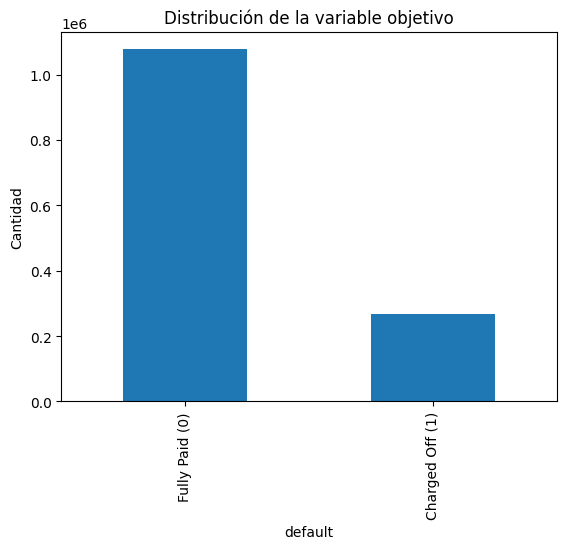

In [6]:
import matplotlib.pyplot as plt

df["default"].value_counts().plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xticks([0,1], ["Fully Paid (0)", "Charged Off (1)"])
plt.ylabel("Cantidad")
plt.show()

El gráfico de barras ilustra visualmente el desbalance entre clases. La barra de **Fully Paid (0)** 
supera el millón de registros, mientras que **Charged Off (1)** se sitúa alrededor de los 268,000, 
confirmando la proporción 4:1 identificada anteriormente. Este desbalance será un factor clave 
a considerar en la estrategia de modelado.

## 2.4 Tipos de variables

Se identifican variables numéricas y categóricas para preparar 
el proceso de modelado.

In [7]:
df.dtypes.value_counts()

float64    113
str         38
int64        1
Name: count, dtype: int64

El dataset cuenta con **152 columnas** distribuidas en tres tipos de datos:

- **float64:** 113 columnas — variables numéricas continuas (montos, tasas, porcentajes, etc.)
- **str/object:** 38 columnas — variables categóricas o de texto
- **int64:** 1 columna — variable numérica entera

Esta composición indica que el preprocesamiento deberá incluir el tratamiento de variables 
categóricas (codificación) y la revisión de columnas numéricas con posibles valores nulos o atípicos.

In [8]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Variables numéricas:", len(numerical_cols))
print("Variables categóricas:", len(categorical_cols))

Variables numéricas: 114
Variables categóricas: 38


C:\Users\PC\AppData\Local\Temp\ipykernel_20712\101531032.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


Se identifican **114 variables numéricas** (int64 y float64) y **38 variables categóricas** (object), 
las cuales serán tratadas de forma diferenciada durante el preprocesamiento.

## 2.5 Análisis de valores nulos

Se evalúa la cantidad de valores faltantes en cada variable.
Esto permitirá definir estrategias de imputación o eliminación.

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
}).head(20)

,Missing Values,Percentage
member_id,1345310,100.000000
next_pymnt_d,1345310,100.000000
orig_projected_additional_accrued_interest,1341551,99.720585
hardship_amount,1339556,99.572292
hardship_last_payment_amount,1339556,99.572292
hardship_length,1339556,99.572292
hardship_status,1339556,99.572292
hardship_reason,1339556,99.572292
deferral_term,1339556,99.572292
hardship_start_date,1339556,99.572292


El análisis de valores nulos revela que varias columnas presentan una cantidad crítica de 
datos faltantes. Las 20 variables con mayor porcentaje de nulos son en su mayoría relacionadas 
con programas de dificultad financiera (*hardship*) y solicitudes conjuntas (*sec_app*):

- **`member_id` y `next_pymnt_d`:** 100% de valores nulos — serán eliminadas por no aportar 
  información útil.
- **Variables `hardship_*`:** Entre 99.57% y 100% de nulos — corresponden a casos excepcionales 
  de reestructuración de deuda, con cobertura mínima en el dataset.
- **Variables `sec_app_*` y `revol_bal_joint`:** Alrededor del 98-99% de nulos — asociadas a 
  solicitudes conjuntas, igualmente poco representadas.

Estas columnas con más del 95% de valores faltantes serán candidatas directas para **eliminación** 
en la etapa de preprocesamiento.

In [10]:
df.to_csv("../data/accepted_clean.csv", index=False)